# 02 - Run Modeling: Pre 24hr

This notebook is the interactive companion to `scripts/run_modeling.py`.

It uses the same reusable modeling modules to:

- load the canonical processed dataset
- derive an experiment-specific binary target
- split train / validation / test data
- select valid modeling features
- train and compare candidate models
- inspect feature importance and threshold behavior
- optionally save outputs using `wtfd.models.artifacts`

The goal is to keep the notebook focused on experiment inspection and interpretation while sharing as much logic as possible with the script workflow.


In [1]:
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from wtfd.models.artifacts import (
    ensure_run_output_dir,
    save_dataframe_artifact,
    save_feature_importance,
    save_model_metrics,
    save_run_metadata,
    save_threshold_sweep,
)
from wtfd.models.experiments import get_experiment_config, list_available_experiments
from wtfd.models.feature_selector import (
    build_feature_matrix,
    summarize_feature_selection,
    validate_no_leakage_columns_in_features,
)
from wtfd.models.metrics import build_threshold_sweep_table
from wtfd.models.model_registry import get_model_config
from wtfd.models.splitter import WindFarmSplitter
from wtfd.models.trainer import WindFaultTrainer
from wtfd.utils.logging_utils import get_logger

logger = get_logger(__name__)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
logger.info("Initialized 02_run_modeling notebook environment.")


2026-03-21 16:27:01 | INFO | __main__ | Initialized 02_run_modeling notebook environment.


## 1. Configuration

In [2]:
# Core paths
PROJ_ROOT = Path("..")
MASTER_DATASET_PATH = PROJ_ROOT / "data" / "processed" / "master_dataset.parquet"
OUTPUT_ROOT = PROJ_ROOT / "artifacts" / "modeling"

# Experiment selection
AVAILABLE_EXPERIMENTS = list_available_experiments()
EXPERIMENT_NAME = "pre_24h"

# Optional model override
MODEL_OVERRIDE = None  # Example: ["logistic", "rf"]

# Split / reproducibility settings
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
N_SPLITS = 5
RANDOM_STATE = 42

# Feature-selection settings
FEATURE_SUBSET = "all"
NUMERIC_ONLY = True

# Saving settings
SAVE_OUTPUTS = True
RUN_NAME = None  # Example: "pre72h_eventtime_manual"

TOP_N_FEATURES = 20

logger.info(
    "Notebook configuration | experiment=%s | numeric_only=%s | feature_subset=%s | save_outputs=%s",
    EXPERIMENT_NAME,
    NUMERIC_ONLY,
    FEATURE_SUBSET,
    SAVE_OUTPUTS,
)

if EXPERIMENT_NAME not in AVAILABLE_EXPERIMENTS:
    raise ValueError(
        f"Unknown EXPERIMENT_NAME='{EXPERIMENT_NAME}'. "
        f"Available: {AVAILABLE_EXPERIMENTS}"
    )

experiment = get_experiment_config(EXPERIMENT_NAME)
model_names = MODEL_OVERRIDE if MODEL_OVERRIDE is not None else experiment["models"]

config_df = pd.DataFrame(
    [
        {
            "experiment_name": EXPERIMENT_NAME,
            "description": experiment["description"],
            "positive_states": ", ".join(experiment["positive_states"]),
            "split_method": experiment["split_method"],
            "optimize_for": experiment["optimize_for"],
            "models": ", ".join(model_names),
            "numeric_only": NUMERIC_ONLY,
            "feature_subset": FEATURE_SUBSET,
            "save_outputs": SAVE_OUTPUTS,
        }
    ]
)
display(config_df)

2026-03-21 16:27:01 | INFO | __main__ | Notebook configuration | experiment=pre_24h | numeric_only=True | feature_subset=all | save_outputs=True
2026-03-21 16:27:01 | INFO | wtfd.models.experiments | Retrieved experiment config 'pre_24h' | models=['logistic', 'rf', 'xgboost'] | optimize_for=f1 | split_method=event_chronological


,experiment_name,description,positive_states,split_method,optimize_for,models,numeric_only,feature_subset,save_outputs
0,pre_24h,Predict faults within the next 24 hours.,"pre_0_24h, event_occurring",event_chronological,f1,"logistic, rf, xgboost",True,all,True


## 2. Load canonical processed dataset and derive the experiment target

In [3]:
if not MASTER_DATASET_PATH.exists():
    logger.error("Master dataset not found: %s", MASTER_DATASET_PATH)
    raise FileNotFoundError(f"Master dataset not found: {MASTER_DATASET_PATH}")

logger.info("Loading canonical dataset from %s", MASTER_DATASET_PATH)
df = pd.read_parquet(MASTER_DATASET_PATH)
logger.info("Loaded canonical dataset with shape=%s", df.shape)

splitter = WindFarmSplitter(n_splits=N_SPLITS, random_state=RANDOM_STATE)

state_col_candidates = [
    "state_name",
    "canonical_state",
    "canonical_state_name",
]
state_col = next((col for col in state_col_candidates if col in df.columns), None)

if state_col is None:
    raise KeyError(
        "Could not find a canonical state column in the master dataset. "
        f"Checked columns: {state_col_candidates}"
    )

logger.info(
    "Building binary target from positive_states=%s using state_col=%s",
    experiment["positive_states"],
    state_col,
)

modeling_df = df.copy()
modeling_df["target"] = modeling_df[state_col].isin(
    experiment["positive_states"]
).astype(int)

logger.info(
    "Constructed modeling dataset for experiment=%s with shape=%s and positive_rate=%.6f",
    EXPERIMENT_NAME,
    modeling_df.shape,
    float(modeling_df["target"].mean()),
)

dataset_summary_df = pd.DataFrame(
    [
        {
            "rows": len(modeling_df),
            "columns": modeling_df.shape[1],
            "unique_farms": modeling_df["farm_id"].nunique() if "farm_id" in modeling_df.columns else pd.NA,
            "unique_turbines": modeling_df["asset_id"].nunique() if "asset_id" in modeling_df.columns else pd.NA,
            "unique_events": modeling_df["event_id"].nunique() if "event_id" in modeling_df.columns else pd.NA,
            "positive_rate": modeling_df["target"].mean(),
        }
    ]
)
display(dataset_summary_df)

state_counts = (
    modeling_df[state_col]
    .value_counts(dropna=False)
    .rename_axis(state_col)
    .reset_index(name="count")
)
display(state_counts)

display(modeling_df.head())

2026-03-21 16:27:01 | INFO | __main__ | Loading canonical dataset from ../data/processed/master_dataset.parquet
2026-03-21 16:27:23 | INFO | __main__ | Loaded canonical dataset with shape=(5242948, 46)
2026-03-21 16:27:23 | INFO | wtfd.models.splitter | Initialized WindFarmSplitter with n_splits=5, random_state=42
2026-03-21 16:27:23 | INFO | __main__ | Building binary target from positive_states=['pre_0_24h', 'event_occurring'] using state_col=state_name
2026-03-21 16:27:32 | INFO | __main__ | Constructed modeling dataset for experiment=pre_24h with shape=(5242948, 46) and positive_rate=0.022813


,rows,columns,unique_farms,unique_turbines,unique_events,positive_rate
0,5242948,46,3,27,95,0.022813


,state_name,count
0,normal,5110385
1,event_occurring,113126
2,pre_24_48h,6480
3,pre_0_24h,6479
4,pre_48_72h,6478


,time_stamp,farm_id,asset_id,amb_temp,wind_speed,pitch_angle,active_power,gen_speed,gearbox_oil_temp,transformer_temp,nacelle_temp,hub_temp,yaw_error,vibration_raw,hydraulic_temp,generator_temp,temp_delta_gearbox,temp_trend_24h,rpm_volatility,temp_divergence,power_efficiency,vibration_magnitude,gearbox_oil_temp_delta_6,gearbox_oil_temp_volatility_6,gearbox_oil_temp_delta_24,gearbox_oil_temp_volatility_24,generator_temp_delta_6,generator_temp_volatility_6,generator_temp_delta_24,generator_temp_volatility_24,active_power_delta_6,active_power_volatility_6,active_power_delta_24,active_power_volatility_24,yaw_error_delta_6,yaw_error_volatility_6,yaw_error_delta_24,yaw_error_volatility_24,event_id,event_label,event_start,event_end,state_label,state_name,is_excluded_buffer,target
0,2022-08-04 06:10:00,A,0,22.0,1.7,24.0,-2.560,35.3,41.0,66.333333,30.0,31.0,129.4,22.1,41.0,31.5,19.0,0.0,0.0,-1.0,-0.521067,22.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0
1,2022-08-04 06:20:00,A,0,22.0,1.7,24.0,-2.556,0.0,41.0,66.333333,30.0,31.0,133.6,0.0,41.0,31.5,19.0,0.0,0.0,-1.0,-0.520252,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0
2,2022-08-04 06:30:00,A,0,22.0,0.9,24.0,-2.712,2.8,41.0,66.333333,30.0,31.0,167.1,5.8,41.0,31.5,19.0,0.0,0.0,-1.0,-3.720165,5.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0
3,2022-08-04 06:40:00,A,0,22.0,1.5,24.0,-2.548,0.4,41.0,66.000000,29.0,30.0,-49.1,1.9,41.0,31.5,19.0,0.0,0.0,-1.0,-0.754963,1.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0
4,2022-08-04 06:50:00,A,0,22.0,1.0,24.0,-2.568,0.0,41.0,65.666667,29.0,30.0,-107.3,0.0,41.0,30.5,19.0,0.0,0.0,-1.0,-2.568000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0


## 3. Create train / validation / test splits

In [4]:
split_method = experiment["split_method"]
logger.info(
    "Creating split using split_method=%s | train=%.2f | val=%.2f | test=%.2f",
    split_method,
    TRAIN_SIZE,
    VAL_SIZE,
    TEST_SIZE,
)

if split_method in {"event_time", "event_chronological"}:
    train_df, val_df, test_df = splitter.get_event_level_time_split(
        modeling_df,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
        test_size=TEST_SIZE,
    )
elif split_method in {"group_time", "grouped_time_by_turbine"}:
    train_df, val_df, test_df = splitter.get_grouped_time_split_by_turbine(
        modeling_df,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
        test_size=TEST_SIZE,
    )
elif split_method in {"global_time", "chronological"}:
    train_df, val_df, test_df = splitter.get_train_val_test_split_by_time(
        modeling_df,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
        test_size=TEST_SIZE,
    )
else:
    raise ValueError(f"Unsupported split_method: {split_method}")

split_sizes_df = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "positive_rate": train_df['target'].mean()},
        {"split": "val", "rows": len(val_df), "positive_rate": val_df['target'].mean()},
        {"split": "test", "rows": len(test_df), "positive_rate": test_df['target'].mean()},
    ]
)
display(split_sizes_df)

2026-03-21 16:27:33 | INFO | __main__ | Creating split using split_method=event_chronological | train=0.70 | val=0.15 | test=0.15
2026-03-21 16:27:33 | INFO | wtfd.models.splitter | Creating event-level time split using event_id_col=event_id with train=0.70, val=0.15, test=0.15 on 5242948 rows
2026-03-21 16:27:43 | INFO | wtfd.models.splitter | Event-level time split created | train_events=66 | val_events=14 | test_events=15 | train_rows=3654427 | val_rows=762179 | test_rows=826342


,split,rows,positive_rate
0,train,3654427,0.023846
1,val,762179,0.010756
2,test,826342,0.029362


## 4. Select valid model features

In [5]:
feature_summary = summarize_feature_selection(
    train_df,
    numeric_only=NUMERIC_ONLY,
    feature_subset=FEATURE_SUBSET,
)
feature_names = feature_summary["selected_features"]
validate_no_leakage_columns_in_features(feature_names)

display(
    pd.DataFrame(
        [
            {
                "n_total_columns": feature_summary["n_total_columns"],
                "n_selected_features": feature_summary["n_selected_features"],
                "numeric_only": NUMERIC_ONLY,
                "feature_subset": FEATURE_SUBSET,
            }
        ]
    )
)
display(pd.Series(feature_names[:50], name="selected_feature").to_frame())

X_train = build_feature_matrix(
    train_df,
    numeric_only=NUMERIC_ONLY,
    feature_subset=FEATURE_SUBSET,
)
y_train = train_df["target"].copy()

X_val = build_feature_matrix(
    val_df,
    numeric_only=NUMERIC_ONLY,
    feature_subset=FEATURE_SUBSET,
)
y_val = val_df["target"].copy()

X_test = build_feature_matrix(
    test_df,
    numeric_only=NUMERIC_ONLY,
    feature_subset=FEATURE_SUBSET,
)
y_test = test_df["target"].copy()

logger.info(
    "Prepared X/y matrices | X_train=%s | X_val=%s | X_test=%s",
    X_train.shape,
    X_val.shape,
    X_test.shape,
)


2026-03-21 16:27:43 | INFO | wtfd.models.feature_selector | Selecting features | shape=(3654427, 46) | numeric_only=True | subset=all
2026-03-21 16:27:45 | INFO | wtfd.models.feature_selector | Selected 35 feature columns.
2026-03-21 16:27:45 | INFO | wtfd.models.feature_selector | Feature summary: total=46 | selected=35


,n_total_columns,n_selected_features,numeric_only,feature_subset
0,46,35,True,all


,selected_feature
0,amb_temp
1,wind_speed
2,pitch_angle
3,active_power
4,gen_speed
5,gearbox_oil_temp
6,transformer_temp
7,nacelle_temp
8,hub_temp
9,yaw_error


2026-03-21 16:27:45 | INFO | wtfd.models.feature_selector | Selecting features | shape=(3654427, 46) | numeric_only=True | subset=all
2026-03-21 16:27:45 | INFO | wtfd.models.feature_selector | Selected 35 feature columns.
2026-03-21 16:27:45 | INFO | wtfd.models.feature_selector | Feature matrix shape: (3654427, 35)
2026-03-21 16:28:23 | INFO | wtfd.models.feature_selector | Selecting features | shape=(762179, 46) | numeric_only=True | subset=all
2026-03-21 16:28:23 | INFO | wtfd.models.feature_selector | Selected 35 feature columns.
2026-03-21 16:28:23 | INFO | wtfd.models.feature_selector | Feature matrix shape: (762179, 35)
2026-03-21 16:28:23 | INFO | wtfd.models.feature_selector | Selecting features | shape=(826342, 46) | numeric_only=True | subset=all
2026-03-21 16:28:24 | INFO | wtfd.models.feature_selector | Selected 35 feature columns.
2026-03-21 16:28:24 | INFO | wtfd.models.feature_selector | Feature matrix shape: (826342, 35)
2026-03-21 16:28:24 | INFO | __main__ | Prepare

## 5. Model tournament

In [6]:
tournament_rows = []
detailed_results = {}

for model_name in model_names:
    model_config = get_model_config(model_name)

    logger.info("Training candidate model: %s", model_name)
    trainer = WindFaultTrainer(
        model_type=model_config["model_type"],
        params=model_config["params"],
        random_state=RANDOM_STATE,
    )

    tuned_threshold = trainer.fit_and_tune(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        optimize_for=experiment["optimize_for"],
    )

    train_metrics = trainer.evaluate_detailed(X_train, y_train)
    val_metrics = trainer.evaluate_detailed(X_val, y_val)
    test_metrics = trainer.evaluate_detailed(X_test, y_test)

    tournament_rows.append(
        {
            "model_name": model_name,
            "model_type": model_config["model_type"],
            "threshold": tuned_threshold,
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
            "test_roc_auc": test_metrics["roc_auc"],
            "test_pr_auc": test_metrics["pr_auc"],
            "test_balanced_accuracy": test_metrics["balanced_accuracy"],
            "test_specificity": test_metrics["specificity"],
        }
    )

    detailed_results[model_name] = {
        "trainer": trainer,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "model_config": model_config,
    }

    gc.collect()

results_df = (
    pd.DataFrame(tournament_rows)
    .sort_values(
        by=["test_f1", "test_recall", "test_precision"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)
display(results_df)


2026-03-21 16:28:24 | INFO | wtfd.models.model_registry | Retrieved model config 'logistic' | model_type=logistic
2026-03-21 16:28:24 | INFO | __main__ | Training candidate model: logistic
2026-03-21 16:28:25 | INFO | wtfd.models.trainer | Initialized WindFaultTrainer | model_type=logistic | random_state=42
2026-03-21 16:28:25 | INFO | wtfd.models.trainer | Running combined fit-and-tune workflow | model_type=logistic
2026-03-21 16:28:25 | INFO | wtfd.models.trainer | Fitting model | model_type=logistic | rows=3654427 | features=35
2026-03-21 16:29:32 | INFO | wtfd.models.trainer | Model fitting complete | model_type=logistic
2026-03-21 16:29:32 | INFO | wtfd.models.trainer | Tuning threshold | model_type=logistic | rows=762179 | optimize_for=f1
2026-03-21 16:29:34 | INFO | wtfd.models.metrics | Computed binary metrics | precision=0.0108 recall=1.0000 f1=0.0213 balanced_accuracy=0.5001
2026-03-21 16:29:35 | INFO | wtfd.models.metrics | Computed binary metrics | precision=0.0108 recall=1

,model_name,model_type,threshold,train_precision,train_recall,train_f1,val_precision,val_recall,val_f1,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_specificity
0,xgboost,xgboost,0.78,0.325224,0.675571,0.439075,0.073635,0.224445,0.110890,0.124795,0.131682,0.128146,0.392988,0.042840,0.551873,0.972064
1,rf,rf,0.62,0.189889,0.782062,0.305581,0.042894,0.336180,0.076081,0.084788,0.144912,0.106981,0.406848,0.034602,0.548797,0.952683
2,logistic,logistic,0.26,0.029214,0.953789,0.056692,0.012970,0.816541,0.025535,0.026942,0.700326,0.051887,0.464775,0.053580,0.467591,0.234856


## 6. Inspect the winning model

In [7]:
best_model_name = results_df.iloc[0]["model_name"]
best_bundle = detailed_results[best_model_name]
best_trainer = best_bundle["trainer"]
best_test_metrics = best_bundle["test_metrics"]

logger.info(
    "Winning model=%s | threshold=%.6f | test_f1=%.6f",
    best_model_name,
    best_trainer.best_threshold,
    best_test_metrics["f1"],
)

metric_snapshot_df = pd.DataFrame(
    [
        {
            "model_name": best_model_name,
            "threshold": best_trainer.best_threshold,
            "precision": best_test_metrics["precision"],
            "recall": best_test_metrics["recall"],
            "f1": best_test_metrics["f1"],
            "roc_auc": best_test_metrics["roc_auc"],
            "pr_auc": best_test_metrics["pr_auc"],
            "balanced_accuracy": best_test_metrics["balanced_accuracy"],
            "specificity": best_test_metrics["specificity"],
        }
    ]
)
display(metric_snapshot_df)


2026-03-21 16:42:36 | INFO | __main__ | Winning model=xgboost | threshold=0.780000 | test_f1=0.128146


,model_name,threshold,precision,recall,f1,roc_auc,pr_auc,balanced_accuracy,specificity
0,xgboost,0.78,0.124795,0.131682,0.128146,0.392988,0.04284,0.551873,0.972064


## 7. Feature importance / coefficient inspection

2026-03-21 16:42:36 | INFO | wtfd.models.trainer | Computed feature importance | model_type=xgboost | n_features=35


,feature,importance
0,vibration_raw,0.087857
1,vibration_magnitude,0.083750
2,nacelle_temp,0.080832
3,wind_speed,0.075163
4,amb_temp,0.059163
5,power_efficiency,0.057438
6,temp_delta_gearbox,0.051353
7,hydraulic_temp,0.046685
8,generator_temp,0.040947
9,temp_divergence,0.040334


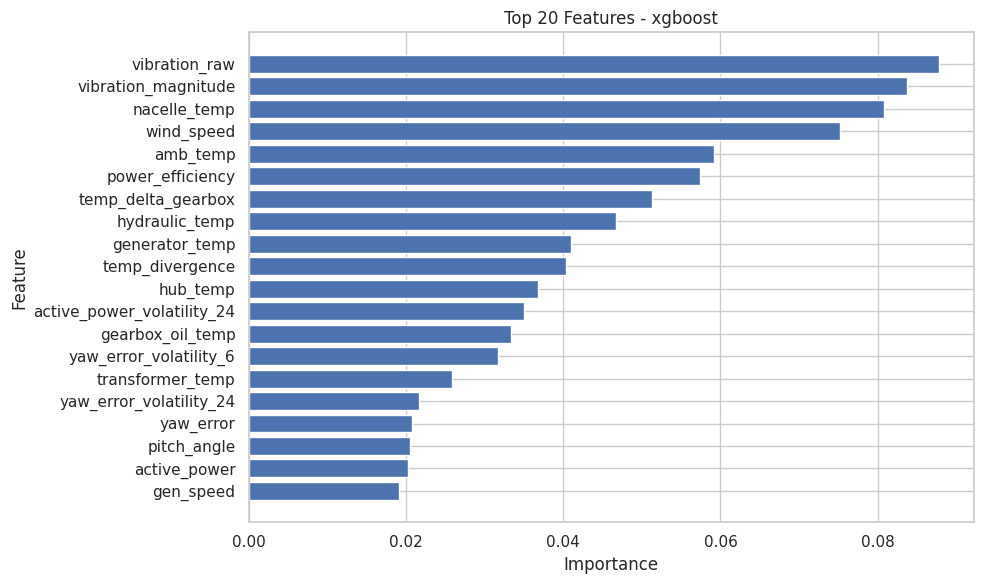

In [8]:
importance_df = best_trainer.get_feature_importance(feature_names).copy()
display(importance_df.head(TOP_N_FEATURES))

plot_df = importance_df.head(TOP_N_FEATURES).iloc[::-1].copy()
value_col = "importance" if "importance" in plot_df.columns else "coefficient"
x_label = "Importance" if value_col == "importance" else "Coefficient"

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df[value_col])
plt.title(f"Top {TOP_N_FEATURES} Features - {best_model_name}")
plt.xlabel(x_label)
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 8. Threshold sweep diagnostics

2026-03-21 16:42:38 | INFO | wtfd.models.metrics | Computed binary metrics | precision=0.0230 recall=0.6589 f1=0.0444 balanced_accuracy=0.4059
2026-03-21 16:42:38 | INFO | wtfd.models.metrics | Computed binary metrics | precision=0.0210 recall=0.5393 f1=0.0404 balanced_accuracy=0.3894
2026-03-21 16:42:39 | INFO | wtfd.models.metrics | Computed binary metrics | precision=0.0188 recall=0.4082 f1=0.0359 balanced_accuracy=0.3816
2026-03-21 16:42:39 | INFO | wtfd.models.metrics | Computed binary metrics | precision=0.0182 recall=0.3701 f1=0.0347 balanced_accuracy=0.3834
2026-03-21 16:42:40 | INFO | wtfd.models.metrics | Computed binary metrics | precision=0.0180 recall=0.3453 f1=0.0342 balanced_accuracy=0.3880
2026-03-21 16:42:40 | INFO | wtfd.models.metrics | Computed binary metrics | precision=0.0176 recall=0.3065 f1=0.0332 balanced_accuracy=0.3940
2026-03-21 16:42:41 | INFO | wtfd.models.metrics | Computed binary metrics | precision=0.0173 recall=0.2784 f1=0.0325 balanced_accuracy=0.3998

,threshold,precision,recall,f1,balanced_accuracy,specificity,false_positive_rate,false_negative_rate,tp,fp,tn,fn,support_positive,support_negative,roc_auc,pr_auc
44,0.82,0.148053,0.119276,0.132116,0.549257,0.979238,0.020762,0.880724,2894,16653,785426,21369,24263,802079,0.392988,0.04284
45,0.84,0.162702,0.110209,0.131407,0.546526,0.982843,0.017157,0.889791,2674,13761,788318,21589,24263,802079,0.392988,0.04284
46,0.86,0.182737,0.102090,0.130996,0.544139,0.986188,0.013812,0.897910,2477,11078,791001,21786,24263,802079,0.392988,0.04284
43,0.80,0.134965,0.125665,0.130149,0.550650,0.975636,0.024364,0.874335,3049,19542,782537,21214,24263,802079,0.392988,0.04284
42,0.78,0.124795,0.131682,0.128146,0.551873,0.972064,0.027936,0.868318,3195,22407,779672,21068,24263,802079,0.392988,0.04284
41,0.76,0.115700,0.136834,0.125382,0.552599,0.968363,0.031637,0.863166,3320,25375,776704,20943,24263,802079,0.392988,0.04284
47,0.88,0.199351,0.091085,0.125039,0.540009,0.988934,0.011066,0.908915,2210,8876,793203,22053,24263,802079,0.392988,0.04284
40,0.75,0.111309,0.139142,0.123679,0.552768,0.966395,0.033605,0.860858,3376,26954,775125,20887,24263,802079,0.392988,0.04284
39,0.74,0.107499,0.141203,0.122067,0.552870,0.964537,0.035463,0.858797,3426,28444,773635,20837,24263,802079,0.392988,0.04284
38,0.72,0.100332,0.144541,0.118446,0.552667,0.960793,0.039207,0.855459,3507,31447,770632,20756,24263,802079,0.392988,0.04284


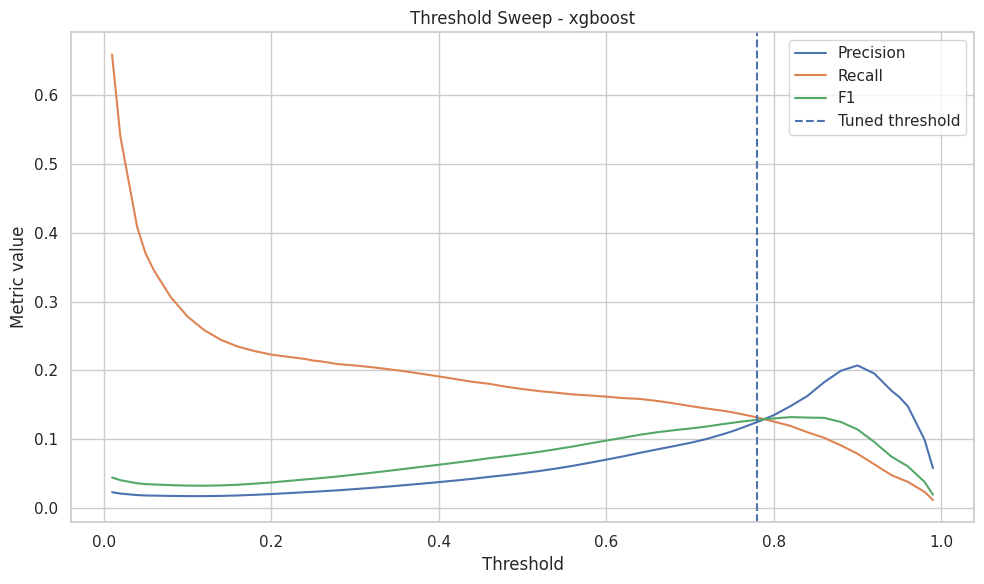

In [9]:
best_test_probs = best_trainer.predict_proba(X_test)
threshold_df = build_threshold_sweep_table(
    y_true=y_test,
    y_prob=best_test_probs,
)

display(
    threshold_df.sort_values(
        by=["f1", "recall", "precision"],
        ascending=[False, False, False],
    ).head(15)
)

plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(best_trainer.best_threshold, linestyle="--", label="Tuned threshold")
plt.title(f"Threshold Sweep - {best_model_name}")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Optional artifact saving

In [10]:
run_dir = None

if SAVE_OUTPUTS:
    run_dir = ensure_run_output_dir(
        base_output_dir=OUTPUT_ROOT,
        experiment_name=EXPERIMENT_NAME,
        run_id=RUN_NAME,
    )

    metadata = {
        "experiment_name": EXPERIMENT_NAME,
        "experiment_config": experiment,
        "data_path": str(MASTER_DATASET_PATH),
        "feature_selection": feature_summary,
        "split_sizes": {
            "train": len(train_df),
            "val": len(val_df),
            "test": len(test_df),
        },
        "best_model_name": best_model_name,
        "best_threshold": float(best_trainer.best_threshold),
        "best_test_metrics": {
            "precision": float(best_test_metrics["precision"]),
            "recall": float(best_test_metrics["recall"]),
            "f1": float(best_test_metrics["f1"]),
            "roc_auc": float(best_test_metrics["roc_auc"]),
            "pr_auc": float(best_test_metrics["pr_auc"]),
            "balanced_accuracy": float(best_test_metrics["balanced_accuracy"]),
            "specificity": float(best_test_metrics["specificity"]),
        },
    }

    summary_metrics = {
        "experiment_name": EXPERIMENT_NAME,
        "best_model_name": best_model_name,
        "best_threshold": float(best_trainer.best_threshold),
        "test_metrics": metadata["best_test_metrics"],
    }

    saved_paths = {
        "results": save_dataframe_artifact(
            results_df,
            run_dir / "model_comparison_summary.csv",
        ),
        "feature_importance": save_feature_importance(
            importance_df,
            run_dir,
        ),
        "threshold_sweep": save_threshold_sweep(
            threshold_df,
            run_dir,
        ),
        "run_metadata": save_run_metadata(
            metadata,
            run_dir,
        ),
        "summary_metrics": save_model_metrics(
            summary_metrics,
            run_dir,
        ),
    }

    logger.info("Saved notebook artifacts to %s", run_dir)
    display(pd.DataFrame([{"artifact": k, "path": str(v)} for k, v in saved_paths.items()]))
else:
    logger.info("SAVE_OUTPUTS=False; no artifacts were written.")
    print("Artifact saving skipped because SAVE_OUTPUTS=False.")


2026-03-21 16:43:10 | INFO | wtfd.models.artifacts | Created modeling run output directory: ../artifacts/modeling/pre_24h/pre_24h_20260321_164310
2026-03-21 16:43:10 | INFO | wtfd.models.artifacts | Saved DataFrame artifact to ../artifacts/modeling/pre_24h/pre_24h_20260321_164310/model_comparison_summary.csv | shape=(3, 16) | index=False
2026-03-21 16:43:10 | INFO | wtfd.models.artifacts | Saved DataFrame artifact to ../artifacts/modeling/pre_24h/pre_24h_20260321_164310/feature_importance.csv | shape=(35, 2) | index=False
2026-03-21 16:43:10 | INFO | wtfd.models.artifacts | Saved DataFrame artifact to ../artifacts/modeling/pre_24h/pre_24h_20260321_164310/threshold_sweep.csv | shape=(55, 16) | index=False
2026-03-21 16:43:10 | INFO | wtfd.models.artifacts | Saved JSON artifact to ../artifacts/modeling/pre_24h/pre_24h_20260321_164310/run_metadata.json | keys=['best_model_name', 'best_test_metrics', 'best_threshold', 'data_path', 'experiment_config', 'experiment_name', 'feature_selection'

,artifact,path
0,results,../artifacts/modeling/pre_24h/pre_24h_20260321...
1,feature_importance,../artifacts/modeling/pre_24h/pre_24h_20260321...
2,threshold_sweep,../artifacts/modeling/pre_24h/pre_24h_20260321...
3,run_metadata,../artifacts/modeling/pre_24h/pre_24h_20260321...
4,summary_metrics,../artifacts/modeling/pre_24h/pre_24h_20260321...


## 10. Optional next steps

Good follow-on experiments for this notebook:

- compare `pre_24h`, `pre_48h`, and `pre_72h`
- compare `include_event=False` vs `include_event=True` in `experiments.py`
- compare `event_time` against `group_time`
- add experiment-specific model overrides
- load prior run outputs from `artifacts/modeling/` for cross-run comparison
